<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/Cluster_Codo3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EJERCICIO 3: AGRUPAMIENTO DE PRODUCTOS SEGÚN VENTAS (K-MEANS)

In [1]:

# 0. Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [2]:
#Crear el dataframe
datos_productos = {
    'Ventas_Mensuales': [2, 3, 2.5, 15, 18, 20, 5, 6, 7],
    'Ingresos_Generados': [3, 4, 3.5, 9, 10, 10, 5, 6, 7]
}
df_productos = pd.DataFrame(datos_productos)
X_productos = df_productos[['Ventas_Mensuales', 'Ingresos_Generados']]

print("--- DataFrame de Productos ---")
print(df_productos)
print("\n" + "="*50 + "\n")


--- DataFrame de Productos ---
   Ventas_Mensuales  Ingresos_Generados
0               2.0                 3.0
1               3.0                 4.0
2               2.5                 3.5
3              15.0                 9.0
4              18.0                10.0
5              20.0                10.0
6               5.0                 5.0
7               6.0                 6.0
8               7.0                 7.0




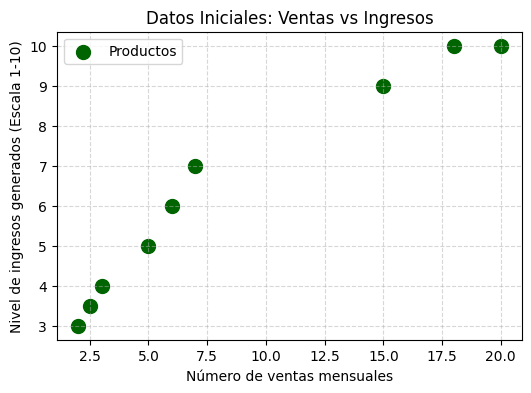

In [3]:
# Graficar los datos iniciales
plt.figure(figsize=(6, 4))
plt.scatter(df_productos['Ventas_Mensuales'], df_productos['Ingresos_Generados'],
            color='darkgreen', s=100, label='Productos')
plt.title('Datos Iniciales: Ventas vs Ingresos')
plt.xlabel('Número de ventas mensuales')
plt.ylabel('Nivel de ingresos generados (Escala 1-10)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [4]:

# 3. Aplicar K-Means con k = 3 & 4. Asignar clusters
k_fijo = 3
kmeans_productos = KMeans(n_clusters=k_fijo, random_state=42, n_init=10)
df_productos['Cluster'] = kmeans_productos.fit_predict(X_productos)

print("--- Productos con Cluster Asignado ---")
print(df_productos)
print("\n" + "="*50 + "\n")

--- Productos con Cluster Asignado ---
   Ventas_Mensuales  Ingresos_Generados  Cluster
0               2.0                 3.0        2
1               3.0                 4.0        2
2               2.5                 3.5        2
3              15.0                 9.0        0
4              18.0                10.0        0
5              20.0                10.0        0
6               5.0                 5.0        1
7               6.0                 6.0        1
8               7.0                 7.0        1




In [5]:
# 5. Obtener centroides
centroides_productos = kmeans_productos.cluster_centers_
print("--- Coordenadas de los Centroides ---")
for i, centroide in enumerate(centroides_productos):
    print(f"Cluster {i}: Ventas Promedio = {centroide[0]:.2f} unidades, Ingresos Promedio = {centroide[1]:.2f}/10")
print("\n" + "="*50 + "\n")

--- Coordenadas de los Centroides ---
Cluster 0: Ventas Promedio = 17.67 unidades, Ingresos Promedio = 9.67/10
Cluster 1: Ventas Promedio = 6.00 unidades, Ingresos Promedio = 6.00/10
Cluster 2: Ventas Promedio = 2.50 unidades, Ingresos Promedio = 3.50/10




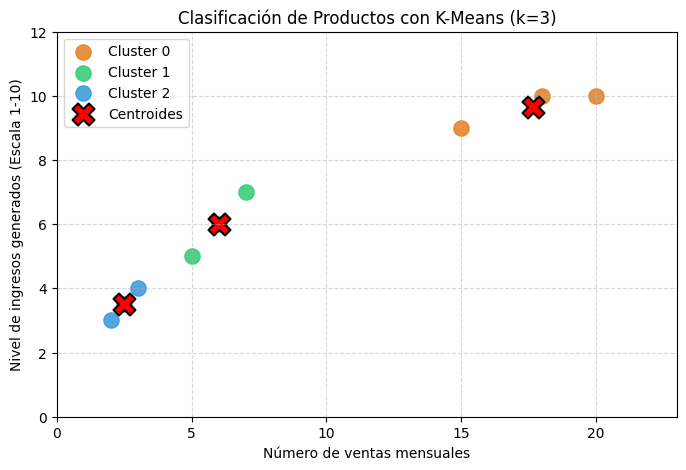

In [6]:
# 6. Visualizar los clusters
plt.figure(figsize=(8, 5))
colores = ['#E67E22', '#2ECC71', '#3498DB'] # Naranja, Verde, Azul

for i in range(k_fijo):
    cluster_mask = df_productos['Cluster'] == i
    plt.scatter(df_productos.loc[cluster_mask, 'Ventas_Mensuales'],
                df_productos.loc[cluster_mask, 'Ingresos_Generados'],
                color=colores[i], s=120, label=f'Cluster {i}', alpha=0.85)

# Graficar los centroides con una "X" roja para que resalten
plt.scatter(centroides_productos[:, 0], centroides_productos[:, 1],
            color='red', marker='X', s=250, label='Centroides', edgecolor='black', linewidth=1.5)

plt.title('Clasificación de Productos con K-Means (k=3)')
plt.xlabel('Número de ventas mensuales')
plt.ylabel('Nivel de ingresos generados (Escala 1-10)')
plt.xlim(0, 23)
plt.ylim(0, 12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

¿Qué tipo de productos representa cada cluster?

Productos de Bajo Rendimiento / Rotación Lenta (Aprox. Ventas: 2.5, Ingresos: ~3.5): Son artículos que se venden muy poco en el mes (de 2 a 3 unidades) y que tampoco aportan márgenes significativos a la empresa (puntuación de ingresos de 3 a 4). Podrían ser productos obsoletos, con baja demanda estacional o que necesitan una revisión de inventario.

Productos Estándar / Desempeño Moderado (Aprox. Ventas: 6.0, Ingresos: ~6.0): Este segmento representa los productos estables del negocio. Mantienen un flujo de ventas constante y equilibrado (de 5 a 7 unidades) junto con una rentabilidad saludable e intermedia (puntuación de 5 a 7). Son el motor recurrente del catálogo.

Productos Estrella / De Alta Rotación (Aprox. Ventas: 17.6, Ingresos: ~9.6): Son los líderes indiscutibles del negocio (bestsellers). Tienen un volumen de ventas masivo (de 15 a 20 unidades al mes) y generan los niveles más altos de ingresos para la organización (puntuaciones casi perfectas de 9 a 10). A este grupo se le suele priorizar el reabastecimiento para evitar quiebres de stock.